In [40]:
import pandas as pd 
import json 
import numpy as np 
import matplotlib.pyplot as plt 
from gensim.parsing.preprocessing import preprocess_string
from gensim.corpora import Dictionary
from gensim.models.lsimodel import LsiModel
from gensim.models import TfidfModel
from gensim.similarities import MatrixSimilarity
from gensim.models.coherencemodel import CoherenceModel 

## TABLE OF CONTENTS (LSI MODEL)
-  Basic Topic Modelling 
-  Coherence score 
- For new document 


## Main topics : 
-  LDA  (+visualization)
-  LSA/LSI
-  BERTopic (+visualization)

In [3]:
data = []
with open("News_Category_Dataset_v3.json", "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))
        
data =  pd.DataFrame(data)[["category","short_description"]]

In [4]:
tokenized_data = []

for text in data["short_description"].values:
    tokenized_data.append(preprocess_string(text))
    
tokenized_data

[['health',
  'expert',
  'said',
  'earli',
  'predict',
  'demand',
  'match',
  'million',
  'dose',
  'new',
  'booster',
  'order',
  'fall'],
 ['subdu',
  'passeng',
  'crew',
  'fled',
  'aircraft',
  'confront',
  'accord',
  'attornei',
  'offic',
  'lo',
  'angel'],
 ['dog', 'understand', 'eaten'],
 ['accident',
  'grown',
  'toothpast',
  'toddler’',
  'toothbrush',
  'scream',
  'like',
  'clean',
  'teeth',
  'carolina',
  'reaper',
  'dip',
  'tabasco',
  'sauc'],
 ['ami',
  'cooper',
  'accus',
  'invest',
  'firm',
  'franklin',
  'templeton',
  'unfairli',
  'fire',
  'brand',
  'racist',
  'video',
  'central',
  'park',
  'encount',
  'went',
  'viral'],
 ['year',
  'old',
  'woman',
  'seen',
  'work',
  'south',
  'carolina',
  'store',
  'thursdai',
  'dead',
  'mondai',
  'famili',
  'report',
  'miss',
  'author',
  'said'],
 ['anchor',
  'new',
  'york’',
  'pix',
  'ask',
  'journalist',
  'michel',
  'ross',
  'finish',
  'interview'],
 ['half',
  'million',


## Basic topic modelling 
- On Bow corpus 
- On TFIDF corpus 

In [5]:
gensim_dict  = Dictionary()

1. On  Bow corpus

In [6]:
gensim_dict =  Dictionary()

bow_corpus =  [gensim_dict.doc2bow(doc,allow_update=True) for doc in tokenized_data]
bow_corpus[:5]

[[(0, 1),
  (1, 1),
  (2, 1),
  (3, 1),
  (4, 1),
  (5, 1),
  (6, 1),
  (7, 1),
  (8, 1),
  (9, 1),
  (10, 1),
  (11, 1),
  (12, 1)],
 [(13, 1),
  (14, 1),
  (15, 1),
  (16, 1),
  (17, 1),
  (18, 1),
  (19, 1),
  (20, 1),
  (21, 1),
  (22, 1),
  (23, 1)],
 [(24, 1), (25, 1), (26, 1)],
 [(27, 1),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 1),
  (32, 1),
  (33, 1),
  (34, 1),
  (35, 1),
  (36, 1),
  (37, 1),
  (38, 1),
  (39, 1),
  (40, 1)],
 [(41, 1),
  (42, 1),
  (43, 1),
  (44, 1),
  (45, 1),
  (46, 1),
  (47, 1),
  (48, 1),
  (49, 1),
  (50, 1),
  (51, 1),
  (52, 1),
  (53, 1),
  (54, 1),
  (55, 1),
  (56, 1),
  (57, 1)]]

In [7]:
model =  LsiModel(corpus=bow_corpus,id2word=gensim_dict,num_topics=20)
model.print_topics()

[(0,
  '0.359*"new" + 0.342*"year" + 0.315*"time" + 0.237*"like" + 0.207*"dai" + 0.204*"peopl" + 0.144*"want" + 0.140*"life" + 0.123*"wai" + 0.121*"know"'),
 (1,
  '0.818*"new" + -0.248*"like" + 0.200*"year" + -0.192*"peopl" + -0.191*"time" + -0.140*"want" + 0.130*"york" + -0.100*"know" + -0.090*"life" + -0.089*"dai"'),
 (2,
  '0.851*"year" + -0.358*"new" + 0.189*"old" + -0.188*"like" + -0.124*"peopl" + -0.084*"want" + 0.062*"ago" + -0.060*"york" + -0.053*"know" + 0.051*"time"'),
 (3,
  '-0.880*"time" + 0.300*"like" + 0.234*"peopl" + 0.169*"year" + 0.103*"want" + 0.072*"look" + 0.055*"know" + 0.055*"old" + 0.041*"said" + 0.034*"love"'),
 (4,
  '-0.797*"like" + 0.438*"peopl" + 0.203*"dai" + 0.177*"want" + -0.117*"look" + -0.115*"time" + -0.067*"feel" + 0.067*"live" + -0.064*"year" + 0.058*"know"'),
 (5,
  '-0.726*"dai" + 0.578*"peopl" + -0.181*"want" + 0.130*"time" + -0.101*"check" + -0.095*"huffpost" + -0.079*"twitter" + -0.074*"facebook" + -0.070*"sure" + -0.065*"pinterest"'),
 (6,
  

2.  On Tfidf Corpus 

In [8]:
tfidf =  TfidfModel(bow_corpus)
tfidf_corpus = tfidf[bow_corpus]

model_tfidf =  LsiModel(tfidf_corpus,num_topics=20,id2word=gensim_dict)
model_tfidf.print_topics()

[(0,
  '0.207*"time" + 0.195*"year" + 0.192*"new" + 0.190*"want" + 0.177*"like" + 0.165*"peopl" + 0.150*"dai" + 0.147*"know" + 0.122*"thing" + 0.120*"look"'),
 (1,
  '-0.352*"check" + -0.338*"pinterest" + -0.337*"facebook" + -0.331*"twitter" + -0.314*"huffpost" + -0.308*"tumblr" + -0.246*"style" + -0.245*"sure" + -0.219*"instagram" + -0.217*"want"'),
 (2,
  '0.684*"trump" + 0.372*"donald" + 0.333*"presid" + 0.167*"said" + -0.142*"time" + -0.109*"know" + 0.104*"republican" + -0.088*"like" + 0.086*"elect" + -0.085*"love"'),
 (3,
  '0.613*"year" + 0.348*"new" + -0.302*"know" + 0.236*"old" + -0.213*"want" + -0.206*"like" + -0.142*"trump" + -0.131*"peopl" + -0.121*"think" + -0.120*"thing"'),
 (4,
  '-0.808*"time" + 0.357*"year" + 0.279*"know" + 0.179*"old" + 0.148*"want" + 0.114*"peopl" + 0.060*"said" + -0.055*"trump" + -0.054*"spend" + -0.051*"dai"'),
 (5,
  '-0.730*"like" + -0.387*"look" + 0.309*"know" + -0.187*"feel" + 0.181*"peopl" + 0.129*"want" + -0.127*"year" + 0.120*"need" + 0.103*"

## Coherence Score
=> finding optimal number of topics 

| Coherence Type | Description                                 | Speed                        |
| -------------- | ------------------------------------------- | ---------------------------- |
| `'u_mass'`     | Uses log-likelihood based on internal model | ⚡ Fastest                    |
| `'c_v'`        | Based on NPMI + cosine similarity           | 🐢 Slower but better quality |
| `'c_npmi'`     | Normalized PMI                              | 🐢 Slowest but most accurate |

=> for faster processing use process =  4, topn  = 10 , tfidf_Corpus[:10000]


In [ ]:
## sample initialization 

coherence = CoherenceModel(
               model=model,
               corpus=tfidf_corpus,
               dictionary=gensim_dict,
               coherence='u_mass')
print("Coherence : " , coherence.get_coherence())
print("Lenght tfidf corpus : ",len(tfidf_corpus))

-4.429379783267193

In [34]:
def calc_coherence_Score(x):
    print(f"Calculating for x  : {x}")
    
    model_tfidf = LsiModel(corpus=tfidf_corpus[:10000],num_topics=x,id2word=gensim_dict)
    coherence_Score =  CoherenceModel(model=model_tfidf,corpus=tfidf_corpus[:10000],dictionary=gensim_dict,coherence="u_mass",processes=4,topn=30)
    print("coherence done ...")
    return coherence_Score.get_coherence()

scores = {}
num_topics = [100,150,200,250]
for x in num_topics:
    scores[str(x)] = calc_coherence_Score(x)
    

print(scores)

    

Calculating for x  : 100
coherence done ...
Calculating for x  : 150
coherence done ...
Calculating for x  : 200
coherence done ...
Calculating for x  : 250
coherence done ...
{'100': -10.153059359437403, '150': -11.111037489544447, '200': -11.936982560905463, '250': -12.73367205220355}


Best N topics : 100


Text(0, 0.5, 'score ')

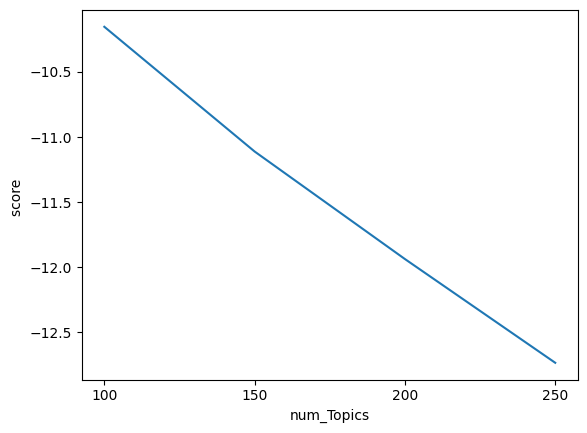

In [35]:
print("Best N topics :",list(scores.keys())[np.argmax(scores.values())])
plt.plot(scores.keys(),scores.values())
plt.xlabel("num_Topics")
plt.ylabel("score ")

## For new Document 

In [85]:
new_texts = [
'The new Windows operating system will be released',
'The system uses the most difficult technologies and techniques',
'The U.S. consumer prices dropped for the first time in ten months'
]
vec_bow =  [gensim_dict.doc2bow(preprocess_string(doc)) for doc in new_texts]
vec_tfidf = [tfidf[doc_bow] for doc_bow in vec_bow]
vec_lsi = [model[doc_tfidf] for doc_tfidf in vec_tfidf]

print("*"*40)
print("Vec bow :\n",vec_bow)
print("*"*40)
print("Vec tfidf :\n",vec_tfidf)
print("*"*40)
print("vec Lsi:\n" ,vec_lsi)

****************************************
Vec bow :
 [[(9, 1), (1123, 1), (1232, 1), (2204, 1)], [(797, 1), (804, 1), (4698, 1), (7021, 1)], [(189, 1), (230, 1), (248, 1), (564, 1), (1664, 1)]]
****************************************
Vec tfidf :
 [[(9, 0.26016026374676526), (1123, 0.4822659436769556), (1232, 0.570242956975874), (2204, 0.6120123910150843)], [(797, 0.48331079608510025), (804, 0.3961864139359157), (4698, 0.6097854397154692), (7021, 0.4874512460864142)], [(189, 0.2603939362708558), (230, 0.5148293749872717), (248, 0.38205011517367005), (564, 0.5107645648646265), (1664, 0.5101989625411042)]]
****************************************
vec Lsi:
 [[(0, 0.10467298816788594), (1, 0.2166581735909295), (2, -0.09440353033238869), (3, -0.008611450010282564), (4, -0.011150700978173098), (5, 0.00962825254624498), (6, -0.0037535622180047464), (7, -0.018501043055613283), (8, -0.012577888154602358), (9, -0.014869440729104639), (10, 0.0003428426575219513), (11, -0.0027318273231307054), (12,

In [90]:
index =  MatrixSimilarity(model[tfidf_corpus])
sims = [index[doc_lsi] for doc_lsi in vec_lsi]

In [106]:
print("Length : ",len(sims), "|| length vector 0 : ",len(sims[0]))
print(sims)


for i, sim in enumerate(sims):
    print(f"\nQuery Document {i}:")
    # Get top 5 most similar docs
    top_matches = sorted(list(enumerate(sim)), key=lambda x: -x[1])[:5]
    for doc_id, score in top_matches:
        print(f"  -> Doc {doc_id} | Score: {score:.4f}")


Length :  3 || length vector 0 :  209527
[array([ 0.64273953,  0.23839913, -0.02032376, ...,  0.02283812,
        0.04230641,  0.05224659], dtype=float32), array([0.25882643, 0.5128725 , 0.8628311 , ..., 0.17399924, 0.33086705,
       0.27344   ], dtype=float32), array([0.04283789, 0.1831437 , 0.12119479, ..., 0.09153965, 0.05836212,
       0.9922651 ], dtype=float32)]

Query Document 0:
  -> Doc 22253 | Score: 0.9997
  -> Doc 78783 | Score: 0.9996
  -> Doc 84412 | Score: 0.9996
  -> Doc 76966 | Score: 0.9996
  -> Doc 48607 | Score: 0.9996

Query Document 1:
  -> Doc 183650 | Score: 0.9839
  -> Doc 132138 | Score: 0.9791
  -> Doc 36098 | Score: 0.9752
  -> Doc 37501 | Score: 0.9748
  -> Doc 207873 | Score: 0.9719

Query Document 2:
  -> Doc 170633 | Score: 0.9992
  -> Doc 35959 | Score: 0.9989
  -> Doc 30713 | Score: 0.9986
  -> Doc 51714 | Score: 0.9986
  -> Doc 173766 | Score: 0.9985


In [107]:
data["short_description"][22253 ]

'"Geostorm," "The Snowman" and other new releases did not fare well.'